# Analysis test - simple (abs) correlation with the library
Calculate best correlation match with abs of Gabor filter library decomposed visual stimulation. 

Also compute spike triggered average (STA) and find it useless. 

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from wavelet_utils import loadFilterParamDict
from analysis_utils import correctNeuronPos, compute_respcorr_split_half, FeatureSearch_correlation_batched

In [2]:
spks_path = r"D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy"

resolution = 2.14 # um/px

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

lib_dim="40_26_8_5_4_4"

dwt_path = Path(temppath) / f"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled_lib{lib_dim}_100_66dwt.npy"

libpath= Path(temppath) / f'gaborLibrary_{lib_dim}.npy'
paramspath = libpath.with_suffix('.json')   

print(libpath)
print(dwt_path)
print(spks_path)

D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_40_26_8_5_4_4.npy
D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled_lib40_26_8_5_4_4_100_66dwt.npy
D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy


In [3]:
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

## Load data

In [4]:
spks=np.load(spks_path)
print(f"spks shape: {spks.shape}")
parent_dir = Path(spks_path).parent
neuron_pos=np.load(parent_dir / 'component_centers.npy')

## converts neuron position in microns
neuron_pos=correctNeuronPos(neuron_pos, resolution)
print(f"neuron_pos shape: {neuron_pos.shape}")

spks shape: (5, 12600, 2254)
neuron_pos shape: (2254, 2)


In [5]:
respcorr = compute_respcorr_split_half(spks)

# top 3 most repeatable neurons
top_neurons = np.argsort(respcorr)[-3:]
print(f"Top 3 most repeatable neurons: {top_neurons}")

Computing split-half correlation per neuron: 100%|██████████| 2254/2254 [00:05<00:00, 407.31it/s]

Top 3 most repeatable neurons: [1852 1820 2188]


## Correlate neural data with decomposed stimulus

In [6]:
## runs correlation analysis

dwt = np.load(dwt_path, mmap_mode='r')
print(f"dwt shape: {dwt.shape}")

mean_spks = np.mean(spks[:, :, :], axis=0)

# restrict dwt to >0
#dwt[dwt < 0] = 0

# take absolute value
dwt=np.abs(dwt)

rfs = FeatureSearch_correlation_batched(dwt, mean_spks)

n_neurons = rfs.shape[0]

dwt shape: (12600, 40, 26, 8, 5, 4, 4)
    stim_flat shape: (12600, 665600) (n_timepoints=12600, n_features=665600)
    resp shape: (12600, 2254) (n_timepoints=12600, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 67/67 [00:19<00:00,  3.41it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :   108.34 MB  | shape=(2254, 12600)  dtype=torch.float32
| S_chunk             :   269.17 MB  | shape=(5600, 12600)  dtype=torch.float32
| rfs_chunk           :    48.15 MB  | shape=(2254, 5600)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   425.65 MB (  3.5%) | RESERVED:  2150.00 MB ( 17.5%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 40, 26, 8, 5, 4, 4) (neurons=2254, feature_dims=(40, 26, 8, 5, 4, 4))


In [7]:
# find absolut maximum RF value across all neurons and features
max_idx = np.unravel_index(np.argmax(rfs), rfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = rfs[max_idx]
print(f"max RF value: {max_value} at index {max_idx}")

max RF value: 0.47237324714660645 at index (316, 17, 23, 2, 3, 3, 0)


In [8]:
# find maximum RF value for each neuron
max_values = []
for my_neuron in range(n_neurons):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]
    max_values.append(max_value)
max_values = np.asarray(max_values)



In [9]:
# save respcorr and max_values for each neuron to a csv file
#import pandas as pd
#df = pd.DataFrame({'respcorr': respcorr, 'max_values': max_values})
#df.to_csv(parent_dir / 'respcorr_max_values.csv', index=False)

In [10]:
#index of largest 20 respcorr values
largest_respcorr_indices = np.argsort(respcorr)[-20:]
print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices])}")
print(f"Mean rfs_correlation of largest 20 neurons: {np.mean(max_values[largest_respcorr_indices])}")

Mean respcorr of largest 20 neurons: 0.734815765831713
Mean rfs_correlation of largest 20 neurons: 0.2924456000328064


In [11]:
my_neuron = 2188
my_neuron = 2119
my_neuron = 1820
my_neuron = 2097
my_neuron = 456 

myrfs = rfs[my_neuron]
max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = myrfs[max_idx]
print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")

Neuron 456 max RF value: 0.314 at index (14, 19, 1, 3, 3, 1), respcorr: 0.743


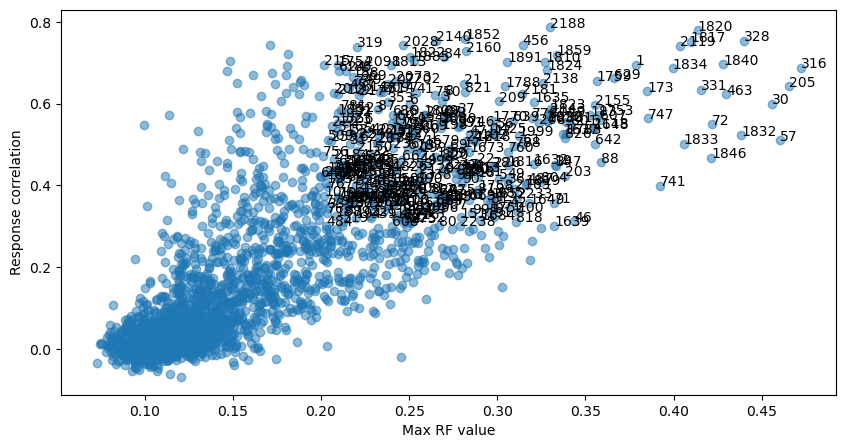

In [12]:
# plot max_values vs respcorr with data labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(max_values, respcorr, alpha=0.5)

for i in range(n_neurons):
    if respcorr[i] > 0.3 and max_values[i] > 0.2: # only label neurons with high repeatability
        plt.annotate(f"{i}", (max_values[i], respcorr[i]))

plt.xlabel('Max RF value')
plt.ylabel('Response correlation')
plt.show()


## Spike Triggered Average - doesn't seem to be useful

In [13]:

library = np.load(libpath, mmap_mode='r')

downsampled_video_path = r"D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled.npy"
downsampled_video=np.load(downsampled_video_path)

if downsampled_video.shape[0] != dwt.shape[0]:
    raise ValueError("downsampled_video and dwt must have the same number of frames")

In [14]:
# calculate STA
s=downsampled_video.shape
video_flat=downsampled_video.reshape(s[0],s[1]*s[2])
n=mean_spks.shape[1]
spks_used=mean_spks.T
sta=np.dot(spks_used,video_flat)/n
sta=sta.reshape(-1,s[1],s[2])

In [15]:
# calculate STA with (time) roll
rollamount=5
sta_m=np.dot(np.roll(spks_used, rollamount,axis=1),video_flat).reshape(-1,s[1],s[2])/n
sta_p=np.dot(np.roll(spks_used,-rollamount,axis=1),video_flat).reshape(-1,s[1],s[2])/n

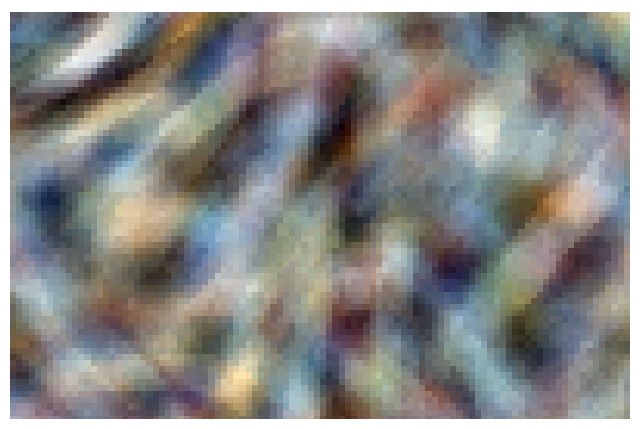

In [16]:
#display for a neuron
ni=30

def normalize(x):
    x = x.astype(np.float32)
    xmin = np.min(x)
    xmax = np.max(x)

    if xmax == xmin:
        return np.zeros_like(x)

    return (x - xmin) / (xmax - xmin)

# stack into RGB image
rgb = np.stack([sta_m[ni].T, sta[ni].T, sta_p[ni].T], axis=-1)
rgb = normalize(rgb)

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis("off")
plt.ylim(0, rgb.shape[0]) #reverse
plt.show()

## Visualization

In [17]:
zoomwidth = 12 # 13hz resampling
zoomwidth = 28 # 30hz resampling

In [ ]:
#interactive plot
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

az_left, az_right, el_bottom, el_top = visual_coverage

param_names = ["x", "y", "angle", "size", "freq", "phase"]
param_values = [xs, ys, angles, sizes, freqs, phases]

resp = mean_spks

n_frames = min(downsampled_video.shape[0], dwt.shape[0], resp.shape[0])
n_neurons = resp.shape[1]

slider_width = "300px"

sliders = [
    widgets.IntSlider(
        value=len(vals) // 2,
        min=0,
        max=len(vals) - 1,
        step=1,
        description=name,
        continuous_update=False,
        layout=widgets.Layout(width=slider_width)
    )
    for name, vals in zip(param_names, param_values)
]

neuron_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_neurons - 1,
    step=1,
    description="neuron",
    layout=widgets.Layout(width=slider_width)
)

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    continuous_update=False,
    layout=widgets.Layout(width="100%")
)

time_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    layout=widgets.Layout(width=slider_width)
)

out_rfs = widgets.Output()
out_time = widgets.Output()
out_overlay = widgets.Output()

_updating_time = False
_updating_neuron = False


def set_sliders_to_neuron_max(my_neuron):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]

    print(
        f"Neuron {my_neuron} max RF value: {max_value:.3f} "
        f"at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}"
    )

    for s, idx in zip(sliders, max_idx):
        s.value = idx


def plot_view(*args):
    xi, yi, anglei, sizei, freqi, phasei = [s.value for s in sliders]
    ti = time_slider.value
    ni = neuron_box.value

    frame = downsampled_video[ti]
    filt = library[xi, yi, anglei, sizei, freqi, phasei, :, :]

    transient = dwt[:n_frames, xi, yi, anglei, sizei, freqi, phasei]
    neuron_trace = resp[:n_frames, ni]

    current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi, phasei]
    current_respcorr = respcorr[ni]

    title_params = (
        f"frame={ti}, neuron={ni}, respcorr={current_respcorr:.4f}, "
        f"rfs={current_rfs:.4f}\n"
        f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
        f"angle={angles[anglei]:.2f}, "
        f"size={sizes[sizei]:.2f}, "
        f"freq={freqs[freqi]:.3f}, "
        f"phase={phases[phasei]:.2f}"
    )

    with out_rfs:
        out_rfs.clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(9, 5))
        axes = axes.flat

        cross_sections = [
            ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi, phasei], xi),
            ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi, phasei], yi),
            ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi, phasei], anglei),
            ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi, phasei], sizei),
            ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :, phasei], freqi),
            ("phase", phases, rfs[ni, xi, yi, anglei, sizei, freqi, :], phasei),
        ]

        for ax, (name, vals, data, idx) in zip(axes, cross_sections):
            ax.plot(vals, data, marker="o")
            ax.axvline(vals[idx], color="red", linestyle="--", linewidth=1.5)
            ax.axhline(0, color="black", linewidth=0.5)
            ax.set_title(f"{name} | rfs={data[idx]:.4f}", fontsize=9)
            ax.set_xlabel(name)
            ax.set_ylabel("rfs")

        fig.suptitle(f"RFS cross-sections — neuron {ni}", fontsize=11)
        plt.tight_layout()
        plt.show()

    with out_time:
        out_time.clear_output(wait=True)

        z0 = max(0, ti - zoomwidth)
        z1 = min(n_frames, ti + zoomwidth+1)
        t_zoom = np.arange(z0, z1)

        fig, (ax_zoom, ax_full) = plt.subplots(
            1, 2,
            figsize=(14, 3.5),
            gridspec_kw={"width_ratios": [1, 2]}
        )

        ax_full.plot(np.arange(n_frames), transient)
        ax_full.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_full.set_xlim(0, n_frames - 1)
        ax_full.set_xlabel("Frame")
        ax_full.set_title(
            f"WT + neuron transient — full | neuron={ni}, respcorr={current_respcorr:.4f}"
        )

        ax_full_r = ax_full.twinx()
        ax_full_r.plot(np.arange(n_frames), neuron_trace, color="orange", alpha=0.8)
        ax_full_r.set_ylabel("Neuron response")

        wt_ylim = ax_full.get_ylim()
        neuron_ylim = ax_full_r.get_ylim()

        ax_zoom.plot(t_zoom, transient[z0:z1], marker="o")
        ax_zoom.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_zoom.set_xlim(z0, z1 - 1)
        ax_zoom.set_ylim(wt_ylim)
        ax_zoom.set_title(f"Zoom ±{zoomwidth} frames")
        ax_zoom.set_xlabel("Frame")
        ax_zoom.set_ylabel("WT response")

        ax_zoom_r = ax_zoom.twinx()
        ax_zoom_r.plot(t_zoom, neuron_trace[z0:z1], color="orange", marker=".")
        ax_zoom_r.set_ylim(neuron_ylim)

        ax_zoom_r.set_yticks([])
        ax_zoom_r.set_ylabel("")
        ax_zoom_r.spines["right"].set_visible(False)

        ax_full.set_yticks([])
        ax_full.set_ylabel("")
        ax_full.spines["left"].set_visible(False)

        plt.tight_layout()
        plt.show()

    with out_overlay:
        out_overlay.clear_output(wait=True)

        fig, (ax, ax_sta) = plt.subplots(1, 2, figsize=(10, 4))

        ax.imshow(
            frame.T,
            cmap="gray",
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="equal",
        )

        filt_plot = filt.T
        v = np.max(np.abs(filt_plot))
        if v == 0:
            v = 1

        rgba = np.zeros((*filt_plot.shape, 4), dtype=float)
        pos = filt_plot > 0
        neg = filt_plot < 0

        rgba[pos, 0] = 1.0
        rgba[neg, 1] = 1.0
        rgba[..., 3] = np.abs(filt_plot) / v * 0.7

        ax.imshow(
            rgba,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        ax.set_title("Video + selected Gabor overlay\n" + title_params)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Elevation (°)")
        
        ax_sta.imshow(sta[ni].T, extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",)
        ax_sta.set_title(f"STA", fontsize=9)
        ax_sta.axvline(xs[xi], color="gray",  linewidth=1)
        ax_sta.axhline(ys[yi], color="gray",  linewidth=1)
        ax_sta.set_xlabel("Azimuth (°)")
        ax_sta.set_ylabel("Elevation (°)")

        plt.tight_layout()
        plt.show()


def sync_time_from_slider(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_box.value = change["new"]
    _updating_time = False
    plot_view()


def sync_time_from_box(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_slider.value = change["new"]
    _updating_time = False
    plot_view()


def update_neuron(change=None):
    global _updating_neuron
    if _updating_neuron:
        return

    _updating_neuron = True
    set_sliders_to_neuron_max(neuron_box.value)
    _updating_neuron = False

    plot_view()


for s in sliders:
    s.observe(plot_view, names="value")

time_slider.observe(sync_time_from_slider, names="value")
time_box.observe(sync_time_from_box, names="value")
neuron_box.observe(update_neuron, names="value")

slider_box = widgets.VBox([neuron_box] + sliders)
top_row = widgets.HBox([slider_box, out_rfs])
time_control = widgets.HBox([time_box, time_slider])

display(top_row, out_time, time_control, out_overlay)

update_neuron()

Output()

Output()

Neuron 0 max RF value: 0.270 at index (16, 20, 7, 4, 2, 0), respcorr: 0.574
